In [120]:
# !pip install matplotlib

In [100]:
import os
cwd = os.getcwd()
print(cwd)

d:\MsC\Thesis\Experiments\DIQKD\src


In [196]:
import numpy as np

def compute_QBER(X, Y, A, B):
    N_XY = [0, 0]
    N_XY_err = [0, 0]

    for x_, y_, a_, b_ in zip(X, Y, A, B):
        x, y, a, b = int(x_), int(y_), int(a_), int(b_)

        if x == y: # same input
            if x == 0 or x == 1: # key round
                N_XY[x] += 1
                if a == b: # error
                    N_XY_err[x] += 1

    Q_0 = float(N_XY_err[0]) / N_XY[0] if N_XY[0] > 0 else 0
    Q_1 = float(N_XY_err[1]) / N_XY[1] if N_XY[1] > 0 else 0
    Q = (Q_0 + Q_1) / 2
    return Q

In [197]:
from collections import defaultdict

chsh_values = defaultdict(list)
qber_values = defaultdict(list)

for x in range(101):
    filename = f"{os.getcwd()}/../data/readout/test_result_{x}.csv"
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                
                if not line or line.startswith("#"):
                    continue

                parts = line.split(",")
                noise_str, chsh_str, X, A, Y, B = parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip(), parts[4].strip(), parts[5].strip()
                
                noise = float(noise_str)
                chsh  = float(chsh_str)
                qber = compute_QBER(X, Y, A, B)
                #print(qber)
                
                chsh_values[noise].append(chsh)
                qber_values[noise].append(qber)

    except FileNotFoundError:
        continue

noises = sorted(chsh_values.keys())
for noise in noises:
    print(f"Noise {noise:.1f}%: {len(chsh_values[noise])} samples")


Noise 0.0%: 50 samples
Noise 1.0%: 50 samples
Noise 2.0%: 50 samples
Noise 3.0%: 50 samples
Noise 4.0%: 50 samples
Noise 5.0%: 50 samples
Noise 6.0%: 50 samples
Noise 7.0%: 50 samples
Noise 8.0%: 50 samples
Noise 9.0%: 50 samples
Noise 10.0%: 50 samples
Noise 11.0%: 50 samples
Noise 12.0%: 50 samples
Noise 13.0%: 50 samples
Noise 14.0%: 50 samples
Noise 15.0%: 50 samples
Noise 16.0%: 50 samples
Noise 17.0%: 50 samples
Noise 18.0%: 50 samples
Noise 19.0%: 50 samples
Noise 20.0%: 50 samples
Noise 21.0%: 50 samples
Noise 22.0%: 50 samples
Noise 23.0%: 50 samples
Noise 24.0%: 50 samples
Noise 25.0%: 50 samples
Noise 26.0%: 50 samples
Noise 27.0%: 50 samples
Noise 28.0%: 50 samples
Noise 29.0%: 50 samples
Noise 30.0%: 50 samples
Noise 31.0%: 50 samples
Noise 32.0%: 50 samples
Noise 33.0%: 50 samples
Noise 34.0%: 50 samples
Noise 35.0%: 50 samples
Noise 36.0%: 50 samples
Noise 37.0%: 50 samples
Noise 38.0%: 50 samples
Noise 39.0%: 50 samples
Noise 40.0%: 50 samples
Noise 41.0%: 50 samples
No

In [198]:
import numpy as np

chsh_mean = np.array([np.mean(chsh_values[n]) for n in noises])
chsh_std  = np.array([np.std(chsh_values[n], ddof=1) for n in noises])

qber_mean = np.array([np.mean(qber_values[n]) for n in noises])
qber_std  = np.array([np.std(qber_values[n], ddof=1) for n in noises])

print(qber_values[0])

print("CHSH 0% noise", chsh_mean[0])
print("QBER 0% noise", qber_mean[0])

print("CHSH 50% noise", chsh_mean[50])
print("QBER 50% noise", qber_mean[50])

print("CHSH 100% noise", chsh_mean[100])
print("QBER 100% noise", qber_mean[100])

[0.2388483825776872, 0.19687137772478258, 0.2189667043876797, 0.17973867039819313, 0.1861413720119522, 0.156130352441763, 0.15982821526299787, 0.17909414121311534, 0.1606197006844417, 0.18072171136677878, 0.17620744104712316, 0.13182518565692328, 0.13588099511174428, 0.14781399452699417, 0.1402284009746468, 0.15148692810457515, 0.15494714140171212, 0.289528228698567, 0.2914239594142742, 0.23236536277769862, 0.2956034845773239, 0.3469965451703766, 0.3717957446691452, 0.21585551257003116, 0.12221656196207095, 0.14425792965252326, 0.1299615570715315, 0.10243543179983858, 0.12027100173210162, 0.09851054577081975, 0.09239871125937331, 0.09649411865839506, 0.08860893606716178, 0.09983555196896848, 0.09199458789040478, 0.09745794681934994, 0.10983243451463791, 0.09577531306090624, 0.10884683480048038, 0.10857134898971009, 0.09302539271617367, 0.09233799601404011, 0.10757214567226764, 0.08852389777727347, 0.11001100110011, 0.09337486186349725, 0.10048566786123245, 0.10307530364372469, 0.104764

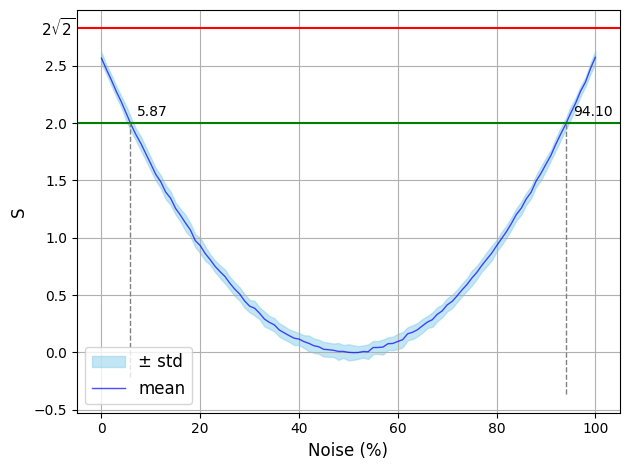

In [199]:
import matplotlib.pyplot as plt
import math

plt.figure()

plt.fill_between(
    noises,
    chsh_mean - chsh_std,
    chsh_mean + chsh_std,
    color='skyblue',
    alpha=0.5,
    label='± std'
)

ideal_chsh = 2 * math.sqrt(2)

plt.plot(noises, chsh_mean, color='blue', linewidth=1, alpha=0.7, label='mean')
plt.axhline(y=2.0, color='g', linestyle='-')
plt.axhline(y=ideal_chsh, color='r', linestyle='-')
plt.annotate(r'$2\sqrt{2}$',
             xy=(0, ideal_chsh),
             xytext=(-1, 0),
             xycoords=('axes fraction', 'data'),
             textcoords='offset points',
             ha='right', va='center',
             fontsize=11)


target = 2.0
# indices where sign changes → crossings
idxs = np.where(np.diff(np.sign(chsh_mean - target)))[0]
x_crossings = []
for idx in idxs:
    x0, x1 = noises[idx], noises[idx+1]
    y0, y1 = chsh_mean[idx], chsh_mean[idx+1]

    # linear interpolation
    x_cross = x0 + (target - y0) * (x1 - x0) / (y1 - y0)
    x_crossings.append(x_cross)
    
for x_cross in x_crossings:
    plt.vlines(x_cross,
               ymin=plt.ylim()[0],   # bottom of plot
               ymax=target,          # intersection (y=2)
               colors='gray',
               linestyles='dashed',
               linewidth=1)

    plt.annotate(f'{x_cross:.2f}',
                 xy=(x_cross, target),
                 xytext=(5, 5),   # slight offset
                 textcoords='offset points',
                 fontsize=10,
                 color='black')

plt.xlabel("Noise (%)", fontsize=12)
plt.ylabel("S", fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../images/plot_noise_CHSH.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [201]:
for e in range(0, 101):
    filename = f'../data/readout/test_result_{e}.csv'

    with open(filename, 'r') as file:
        out_filename = f'../data/shifting/test_result_{e}.csv' + '.dat'
        print(out_filename)
        with open(out_filename, 'w') as out_file:
            for line in file:
                parts = line.split(',')

                n_rounds = len(parts[2])
                #print(n_rounds)
                
                alice_inputs = parts[2].strip()

                alice_outputs = parts[3].strip()

                bob_inputs = parts[4].strip()

                bob_outputs = parts[5].strip()

                # CHSH
                ALICE_INPUT_COUNT = 4
                BOB_INPUT_COUNT = 2
                correlated_count = [[0 for _ in range(BOB_INPUT_COUNT)] for _ in range(ALICE_INPUT_COUNT)]
                anti_correlated_count = [[0 for _ in range(BOB_INPUT_COUNT)] for _ in range(ALICE_INPUT_COUNT)]

                alice_key = ''
                bob_key = ''

                # N_XY = [0, 0]
                # N_XY_err = [0, 0]
                
                for i in range(n_rounds):

                    X = int(alice_inputs[i])
                    Y = int(bob_inputs[i])
                    A = int(alice_outputs[i])
                    B = int(bob_outputs[i])

                    # key round
                    if X == 0 or X == 1:
                        # same input
                        if X == Y:
                            alice_key += str(1 if A == 0 else 0)
                            bob_key += str(B)

                    # test round
                    else:
                        # correlated output
                        if A == B:
                            correlated_count[X][Y] += 1
                        else:
                            anti_correlated_count[X][Y] += 1

                    continue

                #print(correlated_count)
                #print(anti_correlated_count)
                
                E = [[0 for _ in range(BOB_INPUT_COUNT)] for _ in range(ALICE_INPUT_COUNT)]
                for i in range(2, 4):
                    for j in range(0, 2):
                        sum = correlated_count[i][j] + anti_correlated_count[i][j]
                        dif = correlated_count[i][j] - anti_correlated_count[i][j]
                        E[i][j] = float(dif) / sum

                #S = E[2][1] - E[2][0] - E[3][0] - E[3][1]
                #qber = compute_QBER(alice_inputs, bob_inputs, alice_outputs, bob_outputs)
                
                out_file.write(alice_key + ',' + bob_key +'\n')

../data/shifting/test_result_0.csv.dat
../data/shifting/test_result_1.csv.dat
../data/shifting/test_result_2.csv.dat
../data/shifting/test_result_3.csv.dat
../data/shifting/test_result_4.csv.dat
../data/shifting/test_result_5.csv.dat
../data/shifting/test_result_6.csv.dat
../data/shifting/test_result_7.csv.dat
../data/shifting/test_result_8.csv.dat
../data/shifting/test_result_9.csv.dat
../data/shifting/test_result_10.csv.dat
../data/shifting/test_result_11.csv.dat
../data/shifting/test_result_12.csv.dat
../data/shifting/test_result_13.csv.dat
../data/shifting/test_result_14.csv.dat
../data/shifting/test_result_15.csv.dat
../data/shifting/test_result_16.csv.dat
../data/shifting/test_result_17.csv.dat
../data/shifting/test_result_18.csv.dat
../data/shifting/test_result_19.csv.dat
../data/shifting/test_result_20.csv.dat
../data/shifting/test_result_21.csv.dat
../data/shifting/test_result_22.csv.dat
../data/shifting/test_result_23.csv.dat
../data/shifting/test_result_24.csv.dat
../data/sh

In [204]:
import numpy as np
from collections import defaultdict

L = np.zeros((101))
E = np.zeros((101, 21))

qber_cascade_values = defaultdict(list)

for noise in range(0, 101, 1):
    file_path = f'../data/correction/test_result_{noise}.csv.dat.txt'

    with open(file_path, 'r') as file:
        for line in file:
            parts = line.split(',')

            L[noise] += int(parts[0])

            round_id = 0
            for error in parts[1:]:

                E[noise, round_id] += int(error)
                round_id += 1

            qber_cascade = float(parts[-1]) / int(parts[0])
            qber_cascade_values[noise].append(qber_cascade)

for noise in range(0, 101, 1):
    #print(L[noise], E[noise])
    print(qber_cascade_values[noise])

[0.16612377850162866, 0.12634946021591364, 0.16501388337961126, 0.1307752545027408, 0.10493096646942801, 0.08797417271993543, 0.09183258837870784, 0.10301810865191147, 0.08230123851378346, 0.12025316455696203, 0.13004846526655897, 0.06817248459958933, 0.08240277242972661, 0.08473221422861711, 0.09427347097779509, 0.10396039603960396, 0.09678731191541277, 0.19739862280030604, 0.2353896103896104, 0.17582417582417584, 0.22714681440443213, 0.26545884206380466, 0.29589722337339414, 0.1463610776035384, 0.07665232694563942, 0.09380097879282219, 0.07742461287693561, 0.05576055760557606, 0.0713454827452501, 0.06371406371406371, 0.031026252983293555, 0.04872006606110652, 0.0373015873015873, 0.04940304652120214, 0.040930979133226325, 0.03643724696356275, 0.04743083003952569, 0.04286291953093409, 0.04797483287455761, 0.05130293159609121, 0.03345573235414117, 0.03856749311294766, 0.05634920634920635, 0.02540690750297737, 0.06983353633779943, 0.04229848363926576, 0.05942205942205942, 0.0362173038229

[[1.         0.9124777  0.82810368 ... 0.61758841 0.61758841 0.61758841]
 [1.         0.90066778 0.80217028 ... 0.59635106 0.59635106 0.59635106]
 [1.         0.89527521 0.79213346 ... 0.56380906 0.56380906 0.56380906]
 ...
 [1.         0.91951458 0.84028456 ... 0.6396987  0.6396987  0.6396987 ]
 [1.         0.91241939 0.82795923 ... 0.62970668 0.62970668 0.62970668]
 [1.         0.86242961 0.73065165 ... 0.4614642  0.4614642  0.4614642 ]]


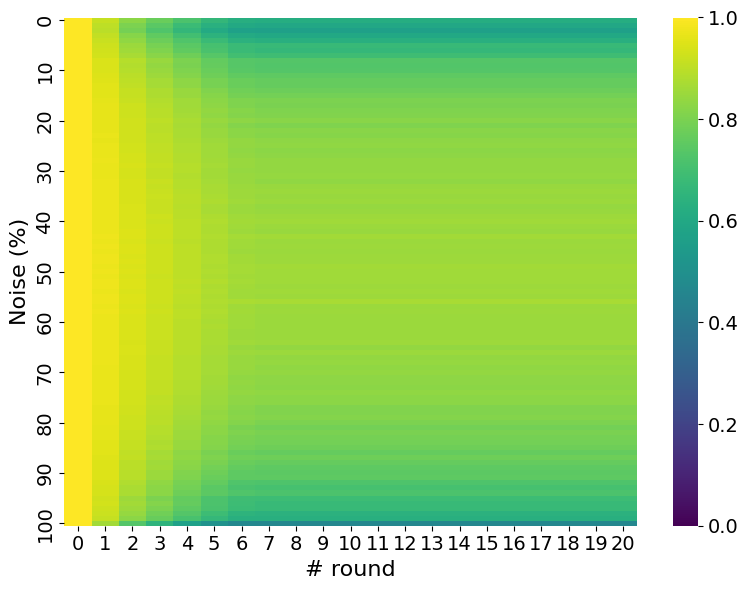

In [205]:
import numpy as np

e_values = np.arange(0, 101)
n_values = np.arange(0, 21)

ratio = E.astype(float) / E[:, [0]]
print(ratio)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    ratio,
    cmap='viridis',
    vmin=0, vmax=1,
    xticklabels=n_values,
    yticklabels=10,
    annot=False, fmt=".2f",
)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.xlabel('# round', fontsize=16)
plt.ylabel('Noise (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("../images/plot_noise_CASCADE.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [212]:
qber_cascade_mean = np.array([np.mean(qber_cascade_values[n]) for n in noises])
qber_cascade_std  = np.array([np.std(qber_cascade_values[n], ddof=1) for n in noises])

print(qber_cascade_mean)
print(qber_mean)

improvement = (qber_mean - qber_cascade_mean) * 100
print(np.average(improvement), improvement)


[0.09412766 0.07983961 0.0739599  0.08839317 0.1003723  0.11778694
 0.12608356 0.14178196 0.17535406 0.17106341 0.18079592 0.19244724
 0.20618662 0.215284   0.22848673 0.24335485 0.26280485 0.27915266
 0.29002392 0.2880207  0.30727493 0.29676941 0.30887784 0.31096789
 0.323845   0.33703128 0.33755224 0.34704309 0.35699218 0.36090274
 0.3643354  0.37070175 0.37018786 0.38643143 0.38829773 0.39267651
 0.39753442 0.39609084 0.40174054 0.40792638 0.41463773 0.41460217
 0.4156379  0.42172865 0.4194556  0.42431245 0.4228051  0.42614268
 0.42584558 0.43123248 0.43178386 0.42690013 0.42756912 0.42572178
 0.42484905 0.42298615 0.43017492 0.41542693 0.42095291 0.41493913
 0.41115721 0.40968956 0.40465901 0.40144951 0.3962912  0.38780381
 0.38850948 0.37874908 0.37775356 0.36925928 0.36682929 0.35569353
 0.35267107 0.34417531 0.34115788 0.32919611 0.32631696 0.31263342
 0.30616141 0.29660949 0.28693667 0.2736649  0.27047584 0.25802756
 0.24694691 0.24222903 0.22254718 0.22636612 0.20492419 0.1992

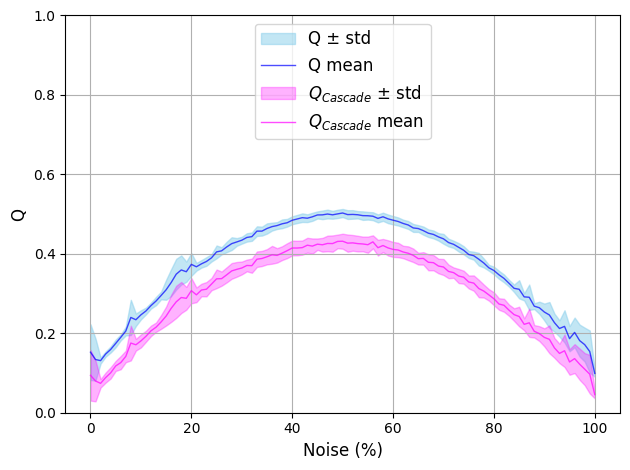

In [209]:
import numpy as np  
import matplotlib.pyplot as plt
import math

fig, ax1 = plt.subplots()

# --- Q ---
ax1.fill_between(
    noises,
    qber_mean - qber_std,
    qber_mean + qber_std,
    color='skyblue',
    alpha=0.5,
    label='Q ± std'
)

ax1.plot(
    noises,
    qber_mean,
    color='blue',
    linewidth=1,
    alpha=0.7,
    label='Q mean'
)

# --- Q_Cascade (same axis) ---
ax1.fill_between(
    noises,
    qber_cascade_mean - qber_cascade_std,
    qber_cascade_mean + qber_cascade_std,
    color='magenta',
    alpha=0.3,
    label='$Q_{Cascade}$ ± std'
)

ax1.plot(
    noises,
    qber_cascade_mean,
    color='magenta',
    linewidth=1,
    alpha=0.7,
    label='$Q_{Cascade}$ mean'
)

# --- Labels & styling ---
ax1.set_xlabel("Noise (%)", fontsize=12)
ax1.set_ylabel("Q", fontsize=12)
ax1.set_ylim(0, 1)
ax1.grid(True)

# --- Single legend ---
ax1.legend(loc='upper center', fontsize=12)

plt.tight_layout()
plt.savefig("../images/plot_noise_QBER_Cascade.pdf", format="pdf", bbox_inches="tight")
plt.show()